# Policing Equity

This notebook prepares the selected policing incident dataset, engineers features, reduces dimensionality, clusters incidents, and saves report-ready tables and figures.

**Selected file**

```text
cpe-data/Dept_49-00081/49-00081_Incident-Reports_2012_to_May_2015.csv
```

The notebook intentionally excludes row identifiers and full street addresses from clustering, because they do not describe general incident similarity and can create very high-dimensional encodings.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 1. Configuration

In [3]:
DATA_PATH = Path("49-00081_Incident-Reports_2012_to_May_2015.csv")
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"

RANDOM_STATE = 42
SVD_COMPONENTS = 50
BEST_K = 4
K_RANGE = range(2, 11)
EVAL_SAMPLE_SIZE = 30_000
SILHOUETTE_SAMPLE_SIZE = 5_000
PLOT_SAMPLE_SIZE = 100_000

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 2. Helper functions

In [4]:
REQUIRED_COLUMNS = [
    "INCIDENT_UNIQUE_IDENTIFIER",
    "INCIDENT_REASON",
    "INCIDENT_REASON_DESCRIPTION",
    "INCIDENT_DAY",
    "INCIDENT_DATE",
    "INCIDENT_TIME",
    "LOCATION_DISTRICT",
    "LOCATION_FULL_STREET_ADDRESS_OR_INTERSECTION",
    "DISPOSITION",
    "LOCATION_LONGITUDE",
    "LOCATION_LATITUDE",
]

MODEL_FEATURES = [
    "incident_reason_simple",
    "INCIDENT_REASON_DESCRIPTION",
    "incident_year",
    "incident_month",
    "incident_dayofweek",
    "incident_time_minutes",
    "is_weekend",
    "time_period",
    "LOCATION_DISTRICT",
    "LOCATION_LONGITUDE",
    "LOCATION_LATITUDE",
    "lat_bin",
    "lon_bin",
    "disposition_simple",
]

NUMERIC_FEATURES = [
    "incident_year",
    "incident_month",
    "incident_dayofweek",
    "incident_time_minutes",
    "is_weekend",
    "LOCATION_LONGITUDE",
    "LOCATION_LATITUDE",
    "lat_bin",
    "lon_bin",
]

CATEGORICAL_FEATURES = [
    "incident_reason_simple",
    "INCIDENT_REASON_DESCRIPTION",
    "time_period",
    "LOCATION_DISTRICT",
    "disposition_simple",
]


def validate_columns(df: pd.DataFrame, required_columns: Iterable[str]) -> None:
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def save_current_figure(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def clean_text(series: pd.Series) -> pd.Series:
    """Clean text values without using pd.NA.

    Using np.nan avoids pandas' "boolean value of NA is ambiguous" errors
    in later boolean operations and plotting.
    """
    cleaned = series.astype("object").where(series.notna(), np.nan)
    cleaned = cleaned.astype(str).str.strip().str.lower()
    cleaned = cleaned.replace(["nan", "none", "<na>", "unknown", "unk", ""], np.nan)
    return cleaned.astype("object")


def minutes_to_time(minutes: float) -> str:
    if pd.isna(minutes):
        return "missing"
    hours = int(minutes // 60)
    mins = int(minutes % 60)
    return f"{hours:02d}:{mins:02d}"


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True, dtype=np.float32)


def top_values(series: pd.Series, n: int = 3) -> str:
    shares = series.fillna("missing").value_counts(normalize=True).head(n)
    return "; ".join([f"{idx}: {val:.1%}" for idx, val in shares.items()])


def sample_dataframe(df: pd.DataFrame, max_rows: int) -> pd.DataFrame:
    if len(df) <= max_rows:
        return df.copy()
    return df.sample(n=max_rows, random_state=RANDOM_STATE).copy()


def sample_array(X: np.ndarray, max_rows: int) -> np.ndarray:
    if X.shape[0] <= max_rows:
        return X
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(X.shape[0], size=max_rows, replace=False)
    return X[idx]

## 3. Load and inspect the dataset

In [5]:
df = pd.read_csv(DATA_PATH, low_memory=False)
validate_columns(df, REQUIRED_COLUMNS)

print("Shape:", df.shape)
df.head()

Shape: (16774, 11)


,INCIDENT_UNIQUE_IDENTIFIER,INCIDENT_REASON,INCIDENT_REASON_DESCRIPTION,INCIDENT_DAY,INCIDENT_DATE,INCIDENT_TIME,LOCATION_DISTRICT,DISPOSITION,LOCATION_FULL_STREET_ADDRESS_OR_INTERSECTION,LOCATION_LONGITUDE,LOCATION_LATITUDE
0,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y
1,120000790,SUSPICIOUS OCC,INVESTIGATIVE DETENTION,Sunday,1/1/12,4:50,SOUTHERN,NONE,0 Block of 7TH ST,-122.4122725,37.78020391
2,120004770,NON-CRIMINAL,LOST PROPERTY,Sunday,1/1/12,1:25,MISSION,NONE,2800 Block of MISSION ST,-122.418434,37.75141993
3,120000712,ASSAULT,"BATTERY, FORMER SPOUSE OR DATING RELATIONSHIP",Sunday,1/1/12,3:35,INGLESIDE,"ARREST, BOOKED",2000 Block of SAN JOSE AV,-122.4439879,37.72397891
4,120064611,NON-CRIMINAL,LOST PROPERTY,Sunday,1/1/12,22:00,INGLESIDE,NONE,300 Block of HEARST AV,-122.4454574,37.73064873


In [6]:
column_groups = {
    "INCIDENT_UNIQUE_IDENTIFIER": "id_like",
    "INCIDENT_REASON": "incident_type",
    "INCIDENT_REASON_DESCRIPTION": "incident_type",
    "INCIDENT_DAY": "date_time",
    "INCIDENT_DATE": "date_time",
    "INCIDENT_TIME": "date_time",
    "LOCATION_DISTRICT": "geographic",
    "LOCATION_FULL_STREET_ADDRESS_OR_INTERSECTION": "geographic",
    "LOCATION_LONGITUDE": "geographic",
    "LOCATION_LATITUDE": "geographic",
    "DISPOSITION": "outcome",
}

column_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_share": df.isna().mean().values,
    "unique_values": df.nunique(dropna=True).values,
})
column_summary["column_group"] = column_summary["column"].map(column_groups).fillna("other")
column_summary = column_summary.sort_values(["column_group", "column"])

column_summary.to_csv(OUTPUT_DIR / "column_summary.csv", index=False)
column_summary

,column,dtype,missing_share,unique_values,column_group
4,INCIDENT_DATE,str,0.00000,88,date_time
3,INCIDENT_DAY,str,0.00000,8,date_time
5,INCIDENT_TIME,str,0.00000,1322,date_time
6,LOCATION_DISTRICT,str,0.00000,11,geographic
8,LOCATION_FULL_STREET_ADDRESS_OR_INTERSECTION,str,0.00000,6097,geographic
10,LOCATION_LATITUDE,str,0.00006,6881,geographic
9,LOCATION_LONGITUDE,str,0.00006,6853,geographic
0,INCIDENT_UNIQUE_IDENTIFIER,str,0.00000,14392,id_like
1,INCIDENT_REASON,str,0.00000,38,incident_type
2,INCIDENT_REASON_DESCRIPTION,str,0.00000,541,incident_type


## 4. Cleaning and feature engineering

The ID column and full street-address column are not used as modelling features. The coordinates and district preserve geographic information with lower dimensionality.

In [7]:
df_clean = df.copy()

# Removes repeated header rows if present.
header_like = (
    df_clean["INCIDENT_UNIQUE_IDENTIFIER"].astype(str).str.upper().eq("INCIDENT_UNIQUE_IDENTIFIER")
    | df_clean["INCIDENT_REASON"].astype(str).str.upper().isin(["INCIDENT_REASON", "CATEGORY"])
)
df_clean = df_clean.loc[~header_like].reset_index(drop=True)

# Cleans text columns.
for col in ["INCIDENT_REASON", "INCIDENT_REASON_DESCRIPTION", "INCIDENT_DAY", "LOCATION_DISTRICT", "DISPOSITION"]:
    df_clean[col] = clean_text(df_clean[col])

# Coordinates must be numeric, not one-hot encoded categories.
df_clean["LOCATION_LONGITUDE"] = pd.to_numeric(df_clean["LOCATION_LONGITUDE"], errors="coerce")
df_clean["LOCATION_LATITUDE"] = pd.to_numeric(df_clean["LOCATION_LATITUDE"], errors="coerce")

# Dates features.
incident_date = pd.to_datetime(df_clean["INCIDENT_DATE"], errors="coerce")
df_clean["incident_year"] = incident_date.dt.year
df_clean["incident_month"] = incident_date.dt.month
df_clean["incident_dayofweek"] = incident_date.dt.dayofweek

# Times as minutes after midnight.
incident_time = pd.to_datetime(df_clean["INCIDENT_TIME"], format="%H:%M", errors="coerce")
df_clean["incident_time_minutes"] = incident_time.dt.hour * 60 + incident_time.dt.minute

# Additional engineered features.
df_clean["is_weekend"] = (
    df_clean["incident_dayofweek"]
    .fillna(-1)
    .isin([5, 6])
    .astype(int)
)

time_period = pd.cut(
    df_clean["incident_time_minutes"],
    bins=[-1, 359, 719, 1079, 1439],
    labels=["night", "morning", "afternoon", "evening"],
)
df_clean["time_period"] = time_period.astype("object").where(time_period.notna(), "missing")

df_clean["lat_bin"] = df_clean["LOCATION_LATITUDE"].round(2)
df_clean["lon_bin"] = df_clean["LOCATION_LONGITUDE"].round(2)
df_clean["incident_reason_simple"] = clean_text(df_clean["INCIDENT_REASON"])
df_clean["disposition_simple"] = clean_text(df_clean["DISPOSITION"])

X_raw = df_clean[MODEL_FEATURES].copy()
X_raw.head()

,incident_reason_simple,INCIDENT_REASON_DESCRIPTION,incident_year,incident_month,incident_dayofweek,incident_time_minutes,is_weekend,time_period,LOCATION_DISTRICT,LOCATION_LONGITUDE,LOCATION_LATITUDE,lat_bin,lon_bin,disposition_simple
0,suspicious occ,investigative detention,2012,1,6,290,1,night,southern,-122.412273,37.780204,37.78,-122.41,NaN
1,non-criminal,lost property,2012,1,6,85,1,night,mission,-122.418434,37.751420,37.75,-122.42,NaN
2,assault,"battery, former spouse or dating relationship",2012,1,6,215,1,night,ingleside,-122.443988,37.723979,37.72,-122.44,"arrest, booked"
3,non-criminal,lost property,2012,1,6,1320,1,evening,ingleside,-122.445457,37.730649,37.73,-122.45,NaN
4,non-criminal,"aided case, mental disturbed",2012,1,6,550,1,morning,tenderloin,-122.415067,37.783563,37.78,-122.42,psychopathic case


In [8]:
feature_summary = pd.DataFrame({
    "column": X_raw.columns,
    "dtype": X_raw.dtypes.astype(str).values,
    "missing_values": X_raw.isna().sum().values,
    "missing_share": X_raw.isna().mean().values,
    "unique_values": X_raw.nunique(dropna=True).values,
}).sort_values("unique_values", ascending=False)

feature_summary.to_csv(OUTPUT_DIR / "feature_summary.csv", index=False)
X_raw.to_csv(OUTPUT_DIR / "policing_equity_features.csv", index=False)
feature_summary

,column,dtype,missing_values,missing_share,unique_values
10,LOCATION_LATITUDE,float64,1,0.00006,6880
9,LOCATION_LONGITUDE,float64,1,0.00006,6852
5,incident_time_minutes,int32,0,0.00000,1321
1,INCIDENT_REASON_DESCRIPTION,object,0,0.00000,540
0,incident_reason_simple,object,0,0.00000,37
12,lon_bin,float64,1,0.00006,15
13,disposition_simple,object,10017,0.59721,15
11,lat_bin,float64,1,0.00006,11
8,LOCATION_DISTRICT,object,0,0.00000,10
4,incident_dayofweek,int32,0,0.00000,7


## 5. Sparse preprocessing

Categorical variables are one-hot encoded as a sparse matrix. This avoids the memory error caused by dense one-hot encoding.

In [9]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", make_one_hot_encoder()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    sparse_threshold=1.0,
)

X_processed = preprocessor.fit_transform(X_raw)

print("Processed shape:", X_processed.shape)
print("Processed type:", type(X_processed))

Processed shape: (16773, 615)
Processed type: <class 'scipy.sparse._csr.csr_matrix'>


## 6. Dimensionality reduction

`TruncatedSVD` is used instead of regular PCA because the encoded data is sparse.

In [10]:
n_components = min(SVD_COMPONENTS, X_processed.shape[1] - 1)
svd_model = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
X_svd = svd_model.fit_transform(X_processed)

svd_df = pd.DataFrame({
    "SVD1": X_svd[:, 0],
    "SVD2": X_svd[:, 1],
})

variance_df = pd.DataFrame({
    "component": np.arange(1, n_components + 1),
    "explained_variance_ratio": svd_model.explained_variance_ratio_,
    "cumulative_explained_variance": svd_model.explained_variance_ratio_.cumsum(),
})

variance_df.to_csv(OUTPUT_DIR / "svd_explained_variance.csv", index=False)
pd.DataFrame(X_svd, columns=[f"SVD_{i + 1}" for i in range(X_svd.shape[1])]).to_csv(
    OUTPUT_DIR / "svd_components.csv", index=False
)

print("SVD shape:", X_svd.shape)
print("Total explained variance:", variance_df["explained_variance_ratio"].sum())
variance_df.tail()

SVD shape: (16773, 50)
Total explained variance: 0.9478488085445343


,component,explained_variance_ratio,cumulative_explained_variance
45,46,0.001048,0.943745
46,47,0.001045,0.944790
47,48,0.001030,0.945820
48,49,0.001023,0.946843
49,50,0.001006,0.947849


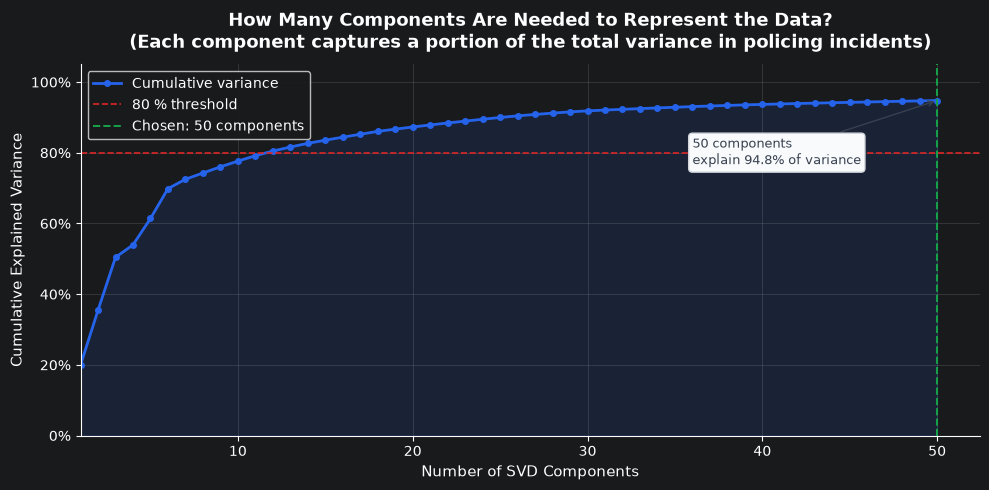

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(variance_df["component"], variance_df["cumulative_explained_variance"],
                alpha=0.12, color="#2563EB")
ax.plot(variance_df["component"], variance_df["cumulative_explained_variance"],
        marker="o", color="#2563EB", linewidth=2, markersize=4, label="Cumulative variance")

ax.axhline(y=0.80, color="#DC2626", linestyle="--", linewidth=1.2, label="80 % threshold")
ax.axvline(x=SVD_COMPONENTS, color="#16A34A", linestyle="--", linewidth=1.4,
           label=f"Chosen: {SVD_COMPONENTS} components")

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_xlim(left=1)
ax.set_ylim(0, 1.05)
ax.set_title("How Many Components Are Needed to Represent the Data?\n"
             "(Each component captures a portion of the total variance in policing incidents)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Number of SVD Components", fontsize=11)
ax.set_ylabel("Cumulative Explained Variance", fontsize=11)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

total_var = variance_df["cumulative_explained_variance"].iloc[-1]
ax.annotate(
    f"{SVD_COMPONENTS} components\nexplain {total_var:.1%} of variance",
    xy=(SVD_COMPONENTS, total_var),
    xytext=(SVD_COMPONENTS - 14, total_var - 0.18),
    arrowprops=dict(arrowstyle="->", color="#374151"),
    fontsize=9, color="#374151",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#F9FAFB", edgecolor="#D1D5DB"),
)
plt.tight_layout()
save_current_figure("svd_cumulative_explained_variance.png")


## 7. Clustering

MiniBatch K-Means is used because the dataset is large. The final cluster number is set in `BEST_K` and can be changed after reviewing the evaluation table and plots.

In [12]:
X_eval = sample_array(X_svd, EVAL_SAMPLE_SIZE)
cluster_eval_rows = []

for k in K_RANGE:
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        batch_size=4096,
        n_init=10,
    )
    labels = model.fit_predict(X_eval)
    sil_sample = min(SILHOUETTE_SAMPLE_SIZE, X_eval.shape[0])

    cluster_eval_rows.append({
        "k": k,
        "silhouette_score": silhouette_score(
            X_eval,
            labels,
            sample_size=sil_sample,
            random_state=RANDOM_STATE,
        ),
        "davies_bouldin_score": davies_bouldin_score(X_eval, labels),
        "inertia": model.inertia_,
    })

cluster_eval = pd.DataFrame(cluster_eval_rows)
cluster_eval.to_csv(OUTPUT_DIR / "cluster_evaluation.csv", index=False)
cluster_eval

,k,silhouette_score,davies_bouldin_score,inertia
0,2,0.148674,2.566830,164214.382306
1,3,0.177101,1.891250,137915.771817
2,4,0.166642,1.798752,125506.039293
3,5,0.131852,2.006991,116303.340516
4,6,0.135824,2.056062,112452.164257
5,7,0.138861,2.092575,106350.632158
6,8,0.117418,2.101485,104912.242276
7,9,0.112629,2.166068,101719.427262
8,10,0.123350,2.103337,97656.176598


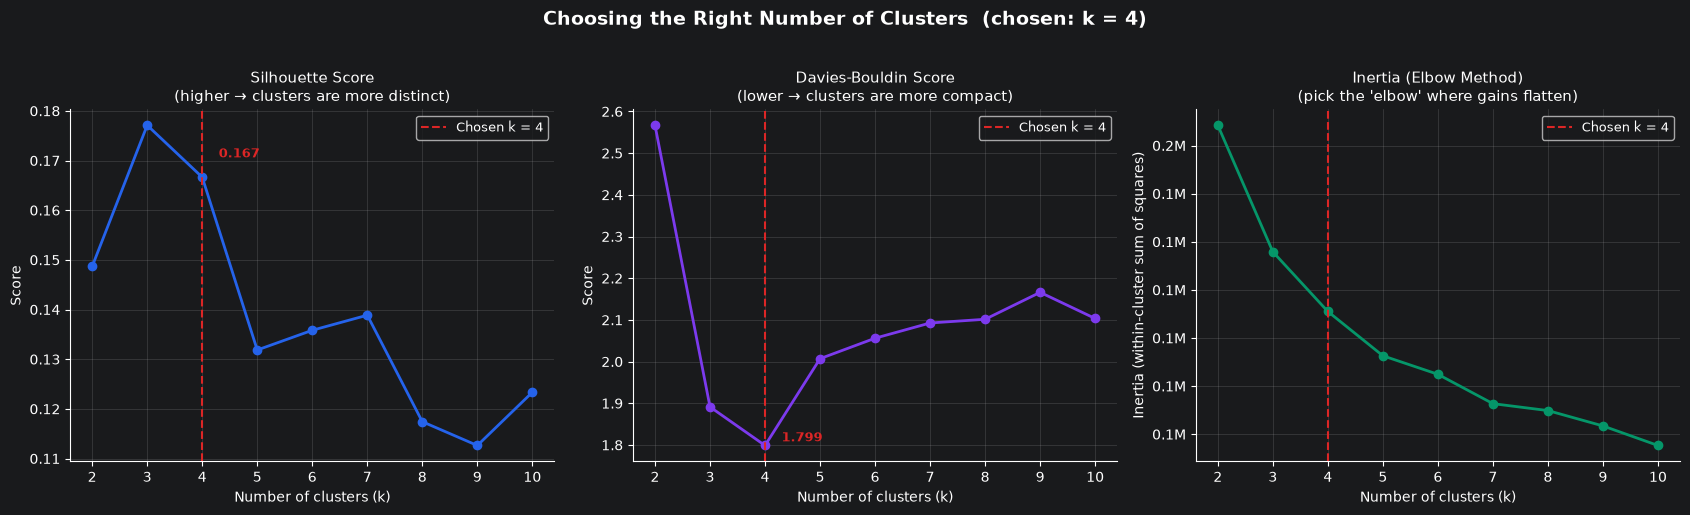

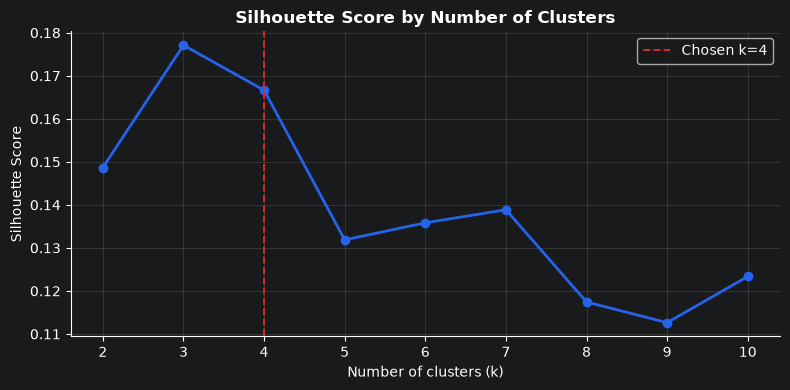

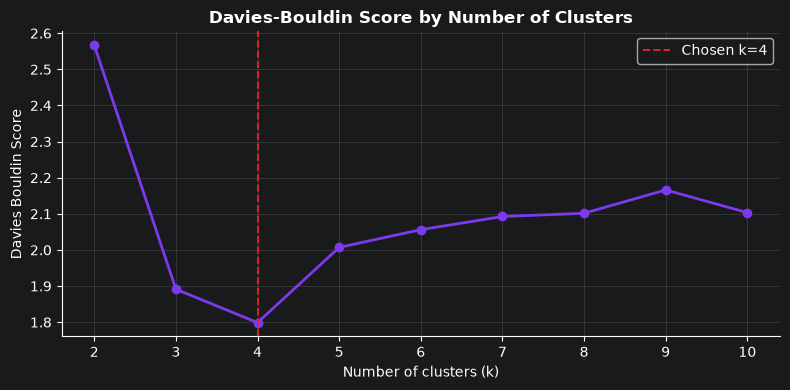

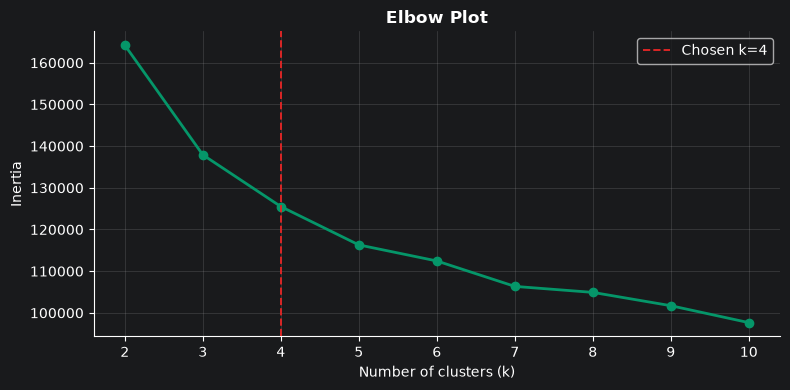

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f"Choosing the Right Number of Clusters  (chosen: k = {BEST_K})",
    fontsize=14, fontweight="bold", y=1.02,
)

# ── Panel 1: Silhouette (higher = better) ──
axes[0].plot(cluster_eval["k"], cluster_eval["silhouette_score"],
             marker="o", color="#2563EB", linewidth=2, markersize=6)
axes[0].axvline(x=BEST_K, color="#DC2626", linestyle="--", linewidth=1.5,
                label=f"Chosen k = {BEST_K}")
best_sil = cluster_eval.loc[cluster_eval["k"] == BEST_K, "silhouette_score"].values[0]
axes[0].annotate(f"{best_sil:.3f}", xy=(BEST_K, best_sil),
                 xytext=(BEST_K + 0.3, best_sil + 0.004),
                 fontsize=9, color="#DC2626", fontweight="bold")
axes[0].set_title("Silhouette Score\n(higher → clusters are more distinct)", fontsize=11)
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Score")
axes[0].legend(fontsize=9)

# ── Panel 2: Davies-Bouldin (lower = better) ──
axes[1].plot(cluster_eval["k"], cluster_eval["davies_bouldin_score"],
             marker="o", color="#7C3AED", linewidth=2, markersize=6)
axes[1].axvline(x=BEST_K, color="#DC2626", linestyle="--", linewidth=1.5,
                label=f"Chosen k = {BEST_K}")
best_db = cluster_eval.loc[cluster_eval["k"] == BEST_K, "davies_bouldin_score"].values[0]
axes[1].annotate(f"{best_db:.3f}", xy=(BEST_K, best_db),
                 xytext=(BEST_K + 0.3, best_db + 0.01),
                 fontsize=9, color="#DC2626", fontweight="bold")
axes[1].set_title("Davies-Bouldin Score\n(lower → clusters are more compact)", fontsize=11)
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Score")
axes[1].legend(fontsize=9)

# ── Panel 3: Elbow / Inertia ──
axes[2].plot(cluster_eval["k"], cluster_eval["inertia"],
             marker="o", color="#059669", linewidth=2, markersize=6)
axes[2].axvline(x=BEST_K, color="#DC2626", linestyle="--", linewidth=1.5,
                label=f"Chosen k = {BEST_K}")
axes[2].set_title("Inertia (Elbow Method)\n(pick the 'elbow' where gains flatten)", fontsize=11)
axes[2].set_xlabel("Number of clusters (k)")
axes[2].set_ylabel("Inertia (within-cluster sum of squares)")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y/1e6:.1f}M"))
axes[2].legend(fontsize=9)

for ax in axes:
    ax.set_xticks(list(K_RANGE))
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
save_current_figure("cluster_evaluation_combined.png")

# Keep individual files as well for backward compatibility
for metric, title, fname, color in [
    ("silhouette_score",    "Silhouette Score by Number of Clusters",  "silhouette_by_k.png",   "#2563EB"),
    ("davies_bouldin_score","Davies-Bouldin Score by Number of Clusters","davies_bouldin_by_k.png","#7C3AED"),
    ("inertia",             "Elbow Plot",                              "elbow_plot.png",          "#059669"),
]:
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    ax2.plot(cluster_eval["k"], cluster_eval[metric], marker="o", color=color, linewidth=2)
    ax2.axvline(x=BEST_K, color="#DC2626", linestyle="--", linewidth=1.4, label=f"Chosen k={BEST_K}")
    ax2.set_title(title, fontsize=12, fontweight="bold")
    ax2.set_xlabel("Number of clusters (k)")
    ax2.set_ylabel(metric.replace("_", " ").title())
    ax2.set_xticks(list(K_RANGE))
    ax2.legend()
    ax2.grid(alpha=0.25)
    ax2.spines[["top", "right"]].set_visible(False)
    save_current_figure(fname)


In [14]:
final_model = MiniBatchKMeans(
    n_clusters=BEST_K,
    random_state=RANDOM_STATE,
    batch_size=4096,
    n_init=10,
)
cluster_labels = final_model.fit_predict(X_svd)

df_clustered = df_clean.copy()
df_clustered["cluster"] = cluster_labels
svd_df["cluster"] = cluster_labels

cluster_counts = df_clustered["cluster"].value_counts().sort_index().reset_index()
cluster_counts.columns = ["cluster", "number_of_incidents"]
cluster_counts["share_of_total"] = (cluster_counts["number_of_incidents"] / len(df_clustered)).round(4)

cluster_counts.to_csv(OUTPUT_DIR / "cluster_counts.csv", index=False)
cluster_counts

,cluster,number_of_incidents,share_of_total
0,0,2384,0.1421
1,1,6775,0.4039
2,2,4285,0.2555
3,3,3329,0.1985


## 8. Cluster interpretation

In [15]:
numeric_profile_cols = [
    "incident_year",
    "incident_month",
    "incident_dayofweek",
    "incident_time_minutes",
    "LOCATION_LONGITUDE",
    "LOCATION_LATITUDE",
]

numeric_cluster_summary = (
    df_clustered
    .groupby("cluster")[numeric_profile_cols]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)
numeric_cluster_summary.to_csv(OUTPUT_DIR / "numeric_cluster_summary.csv")
numeric_cluster_summary

incident_year                     incident_month                 \
                 mean  median   min   max           mean median min max   
cluster                                                                   
0              2012.0  2012.0  2012  2012           1.97    2.0   1   3   
1              2012.0  2012.0  2012  2012           1.93    2.0   1   3   
2              2012.0  2012.0  2012  2012           1.95    2.0   1   3   
3              2012.0  2012.0  2012  2012           1.97    2.0   1   3   

        incident_dayofweek         ... incident_time_minutes        \
                      mean median  ...                   min   max   
cluster                            ...                               
0                     2.97    3.0  ...                     1  1439   
1                     2.10    2.0  ...                     1  1439   
2                     5.53    6.0  ...                     1  1439   
3                     1.96    2.0  ...                     1  1439   

        LOCATION_LONGITUDE                         LOCATION_LATITUDE         \
                      mean  median     min     max              mean median   
cluster                                                                       
0                  -122.47 -122.47 -122.51 -122.44             37.76  37.76   
1                  -122.42 -122.41 -122.45 -122.37             37.78  37.78   
2                  -122.41 -122.41 -122.46 -122.37             37.77  37.78   
3                  -122.41 -122.41 -122.46 -122.37             37.74  37.74   

                       
           min    max  
cluster                
0        37.71  37.79  
1        37.76  37.81  
2        37.71  37.81  
3        37.71  37.76  

[4 rows x 24 columns]

In [16]:
cluster_interpretation = []

for cluster_id, group in df_clustered.groupby("cluster"):
    cluster_interpretation.append({
        "cluster": cluster_id,
        "number_of_incidents": len(group),
        "share_of_total": round(len(group) / len(df_clustered) * 100, 2),
        "top_incident_reasons": top_values(group["incident_reason_simple"]),
        "top_reason_descriptions": top_values(group["INCIDENT_REASON_DESCRIPTION"]),
        "top_days": top_values(group["INCIDENT_DAY"]),
        "top_time_periods": top_values(group["time_period"]),
        "top_districts": top_values(group["LOCATION_DISTRICT"]),
        "top_dispositions": top_values(group["disposition_simple"]),
        "avg_incident_time": minutes_to_time(group["incident_time_minutes"].mean()),
        "avg_latitude": round(group["LOCATION_LATITUDE"].mean(), 5),
        "avg_longitude": round(group["LOCATION_LONGITUDE"].mean(), 5),
    })

cluster_interpretation_df = pd.DataFrame(cluster_interpretation)
cluster_interpretation_df.to_csv(OUTPUT_DIR / "final_cluster_summary_for_report.csv", index=False)

df_clustered.to_csv(OUTPUT_DIR / "policing_equity_clustered.csv", index=False)
svd_df.to_csv(OUTPUT_DIR / "svd_2d_coordinates.csv", index=False)

cluster_interpretation_df

,cluster,number_of_incidents,share_of_total,top_incident_reasons,top_reason_descriptions,top_days,top_time_periods,top_districts,top_dispositions,avg_incident_time,avg_latitude,avg_longitude
0,0,2384,14.21,larceny/theft: 18.4%; other offenses: 14.6%; n...,grand theft from locked auto: 6.3%; malicious ...,friday: 18.0%; thursday: 16.5%; wednesday: 13.9%,afternoon: 35.4%; evening: 29.6%; morning: 22.1%,taraval: 51.6%; richmond: 31.5%; park: 15.5%,"missing: 66.2%; arrest, booked: 14.3%; arrest,...",13:39,37.75564,-122.47426
1,1,6775,40.39,larceny/theft: 21.4%; other offenses: 13.9%; n...,grand theft from locked auto: 6.6%; lost prope...,thursday: 21.8%; friday: 21.6%; wednesday: 20.1%,afternoon: 33.2%; evening: 32.7%; morning: 20.5%,southern: 30.1%; northern: 19.0%; tenderloin: ...,"missing: 57.3%; arrest, booked: 26.2%; arrest,...",13:55,37.78228,-122.41541
2,2,4285,25.55,larceny/theft: 20.7%; other offenses: 14.1%; n...,grand theft from locked auto: 6.3%; lost prope...,sunday: 52.5%; saturday: 47.5%,afternoon: 31.6%; evening: 30.0%; night: 21.3%,southern: 22.3%; mission: 15.2%; central: 12.9%,"missing: 60.3%; arrest, booked: 22.4%; arrest,...",12:56,37.77025,-122.41484
3,3,3329,19.85,other offenses: 19.0%; larceny/theft: 11.5%; a...,"stolen automobile: 5.1%; drivers license, susp...",monday: 21.3%; wednesday: 21.0%; tuesday: 20.5%,afternoon: 33.6%; evening: 33.4%; morning: 21.6%,bayview: 39.4%; ingleside: 33.8%; mission: 25.3%,"missing: 59.3%; arrest, booked: 18.8%; arrest,...",14:09,37.73728,-122.41281


## 9. Final visualizations

Legends for stacked bar charts are placed outside the plot area. Incident reasons are reduced to top categories + `other` to keep the figure readable.

In [17]:
_CLUSTER_PALETTE = [
    "#2563EB", "#DC2626", "#16A34A", "#D97706",
    "#7C3AED", "#0891B2", "#DB2777", "#65A30D",
    "#EA580C", "#0F766E",
]


def _cluster_label(val: int | str) -> str:
    """Convert a raw cluster id (0-9) to a readable label."""
    try:
        return f"Cluster {int(val)}"
    except (ValueError, TypeError):
        return str(val)


def plot_stacked_distribution(
    data: pd.DataFrame,
    row_col: str,
    category_col: str,
    title: str,
    filename: str,
    top_n: int | None = 10,
    normalize: bool = True,
    legend_title: str | None = None,
) -> pd.DataFrame:
    plot_df = data[[row_col, category_col]].copy()
    plot_df[category_col] = plot_df[category_col].fillna("missing").astype(str)

    if top_n is not None:
        top_categories = plot_df[category_col].value_counts().head(top_n).index
        keep_mask = plot_df[category_col].isin(top_categories).fillna(False)
        plot_df[category_col] = plot_df[category_col].where(keep_mask, "other")

    table = pd.crosstab(
        plot_df[row_col], plot_df[category_col],
        normalize="index" if normalize else False,
    ).round(3)

    # Human-readable row labels when the row axis is the cluster column
    is_cluster_rows = (row_col == "cluster")
    if is_cluster_rows:
        table.index = [_cluster_label(i) for i in table.index]

    # Human-readable column labels when the category is the cluster column
    if category_col == "cluster":
        table.columns = [_cluster_label(c) for c in table.columns]

    # Color palette: consistent cluster colours when applicable
    if is_cluster_rows:
        bar_colors = plt.cm.tab20.colors[:len(table.columns)]
    elif category_col == "cluster":
        n_clusters = len(table.columns)
        bar_colors = [_CLUSTER_PALETTE[i % len(_CLUSTER_PALETTE)] for i in range(n_clusters)]
    else:
        bar_colors = plt.cm.tab20.colors[:len(table.columns)]

    fig, ax = plt.subplots(figsize=(12, 6))
    table.plot(kind="bar", stacked=True, ax=ax,
               color=bar_colors, edgecolor="white", linewidth=0.4)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(
        "Cluster" if is_cluster_rows else row_col.replace("_", " ").title(),
        fontsize=11,
    )
    ax.set_ylabel(
        "Share of incidents within cluster (%)" if normalize else "Number of incidents",
        fontsize=11,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0 if len(table) <= 8 else 45,
                       ha="right" if len(table) > 8 else "center", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)

    if normalize:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
        ax.set_ylim(0, 1.12)

        # Annotate the dominant category in each stacked bar
        for i, (_, row_data) in enumerate(table.iterrows()):
            dominant_cat = row_data.idxmax()
            dominant_share = row_data.max()
            if dominant_share >= 0.25:
                label = f"{dominant_cat}\n{dominant_share:.0%}"
                ax.text(
                    i, 1.01, label,
                    ha="center", va="bottom", fontsize=7.5,
                    color="#374151", fontstyle="italic",
                )
    else:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))

    ax.legend(
        title=legend_title or category_col.replace("_", " ").title(),
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        fontsize=9,
        title_fontsize=10,
        framealpha=0.92,
    )

    plt.tight_layout()
    save_current_figure(filename)
    return table


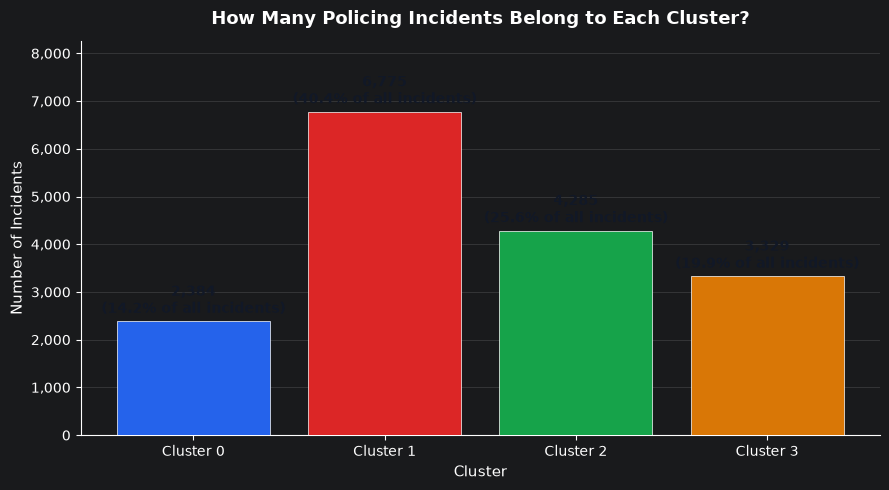

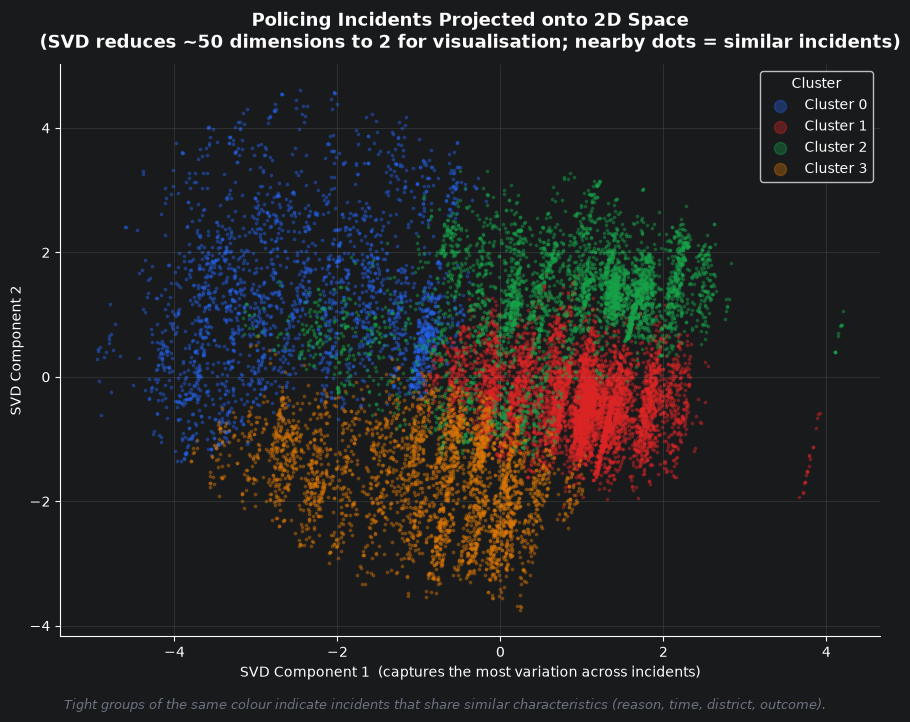

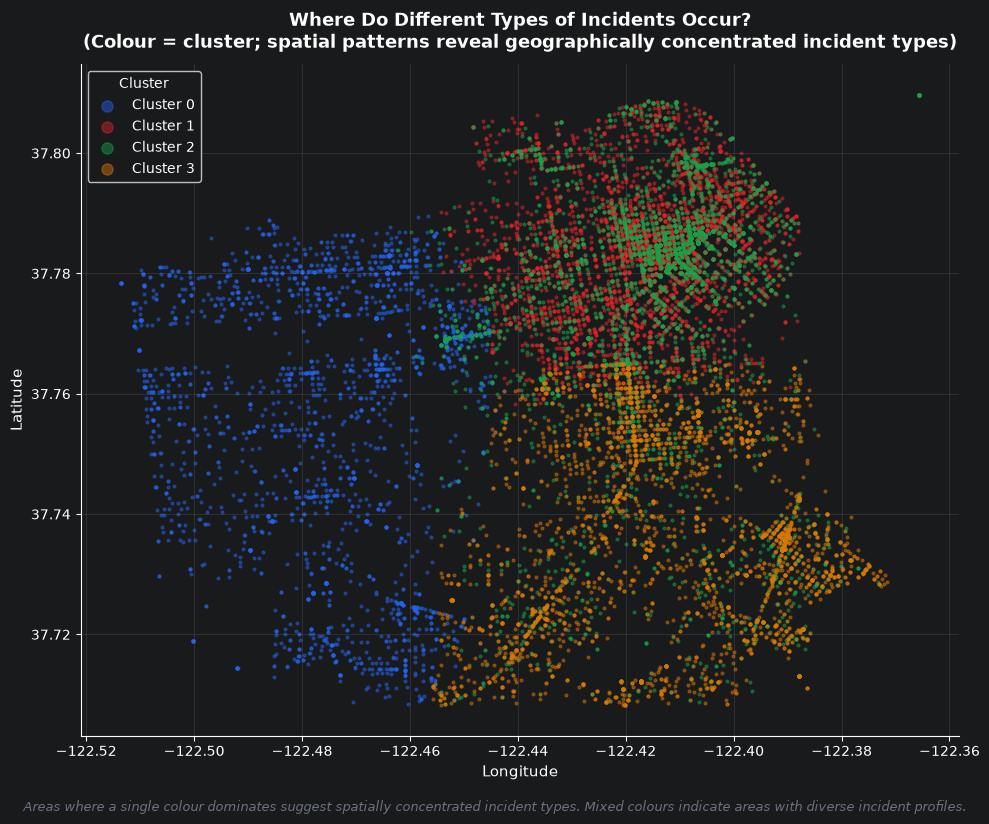

In [18]:
_CLUSTER_PALETTE = [
    "#2563EB", "#DC2626", "#16A34A", "#D97706",
    "#7C3AED", "#0891B2", "#DB2777", "#65A30D",
    "#EA580C", "#0F766E",
]

# ── 1. Number of incidents per cluster ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
cluster_labels_str = [f"Cluster {c}" for c in cluster_counts["cluster"]]
bar_colors = [_CLUSTER_PALETTE[i % len(_CLUSTER_PALETTE)] for i in range(len(cluster_counts))]

bars = ax.bar(cluster_labels_str, cluster_counts["number_of_incidents"],
              color=bar_colors, edgecolor="white", linewidth=0.5, zorder=3)

for bar, (_, row) in zip(bars, cluster_counts.iterrows()):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height + cluster_counts["number_of_incidents"].max() * 0.012,
        f'{int(height):,}\n({row["share_of_total"]:.1%} of all incidents)',
        ha="center", va="bottom", fontsize=10, fontweight="bold", color="#111827",
    )

ax.set_title("How Many Policing Incidents Belong to Each Cluster?",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Cluster", fontsize=11)
ax.set_ylabel("Number of Incidents", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))
ax.set_ylim(0, cluster_counts["number_of_incidents"].max() * 1.22)
ax.grid(axis="y", alpha=0.25, zorder=0)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save_current_figure("incidents_per_cluster.png")


# ── 2. 2D SVD cluster scatter ────────────────────────────────────────────────
svd_plot_df = sample_dataframe(svd_df, PLOT_SAMPLE_SIZE)
fig, ax = plt.subplots(figsize=(9, 7))

for cluster_id in sorted(svd_plot_df["cluster"].unique()):
    mask = svd_plot_df["cluster"] == cluster_id
    color = _CLUSTER_PALETTE[cluster_id % len(_CLUSTER_PALETTE)]
    ax.scatter(
        svd_plot_df.loc[mask, "SVD1"],
        svd_plot_df.loc[mask, "SVD2"],
        c=color, s=3, alpha=0.35,
        label=f"Cluster {cluster_id}",
        rasterized=True,
    )

ax.set_title(
    "Policing Incidents Projected onto 2D Space\n"
    "(SVD reduces ~50 dimensions to 2 for visualisation; nearby dots = similar incidents)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("SVD Component 1  (captures the most variation across incidents)", fontsize=10)
ax.set_ylabel("SVD Component 2", fontsize=10)
ax.legend(title="Cluster", markerscale=5, fontsize=10, title_fontsize=10,
          loc="best", framealpha=0.92)
ax.grid(alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.5, -0.02,
         "Tight groups of the same colour indicate incidents that share similar characteristics "
         "(reason, time, district, outcome).",
         ha="center", fontsize=9, color="#6B7280", style="italic")
plt.tight_layout()
save_current_figure("svd_clusters_2d.png")


# ── 3. Geographic scatter ────────────────────────────────────────────────────
geo_plot_df = df_clustered.dropna(subset=["LOCATION_LONGITUDE", "LOCATION_LATITUDE"])
geo_plot_df = geo_plot_df[
    geo_plot_df["LOCATION_LONGITUDE"].between(-180, 180)
    & geo_plot_df["LOCATION_LATITUDE"].between(-90, 90)
]
geo_plot_df = sample_dataframe(geo_plot_df, PLOT_SAMPLE_SIZE)

fig, ax = plt.subplots(figsize=(10, 8))

for cluster_id in sorted(geo_plot_df["cluster"].unique()):
    mask = geo_plot_df["cluster"] == cluster_id
    color = _CLUSTER_PALETTE[cluster_id % len(_CLUSTER_PALETTE)]
    ax.scatter(
        geo_plot_df.loc[mask, "LOCATION_LONGITUDE"],
        geo_plot_df.loc[mask, "LOCATION_LATITUDE"],
        c=color, s=4, alpha=0.45,
        label=f"Cluster {cluster_id}",
        rasterized=True,
    )

ax.set_title(
    "Where Do Different Types of Incidents Occur?\n"
    "(Colour = cluster; spatial patterns reveal geographically concentrated incident types)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude", fontsize=11)
ax.legend(title="Cluster", markerscale=4, fontsize=10, title_fontsize=10,
          loc="best", framealpha=0.92)
ax.grid(alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.5, -0.02,
         "Areas where a single colour dominates suggest spatially concentrated incident types. "
         "Mixed colours indicate areas with diverse incident profiles.",
         ha="center", fontsize=9, color="#6B7280", style="italic")
plt.tight_layout()
save_current_figure("geographic_cluster_distribution.png")


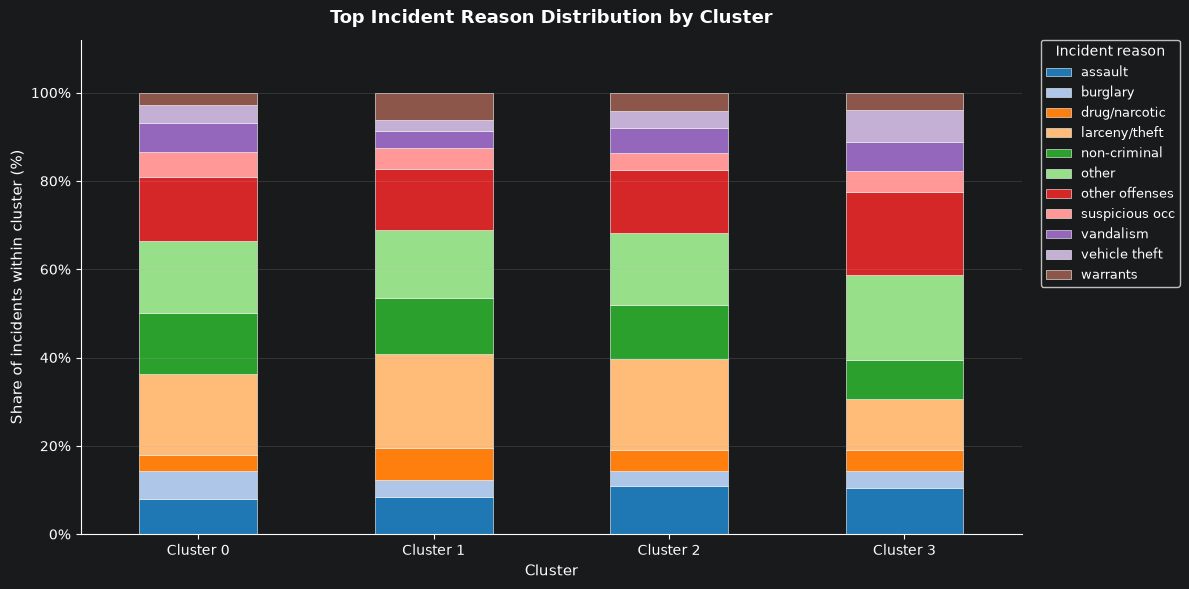

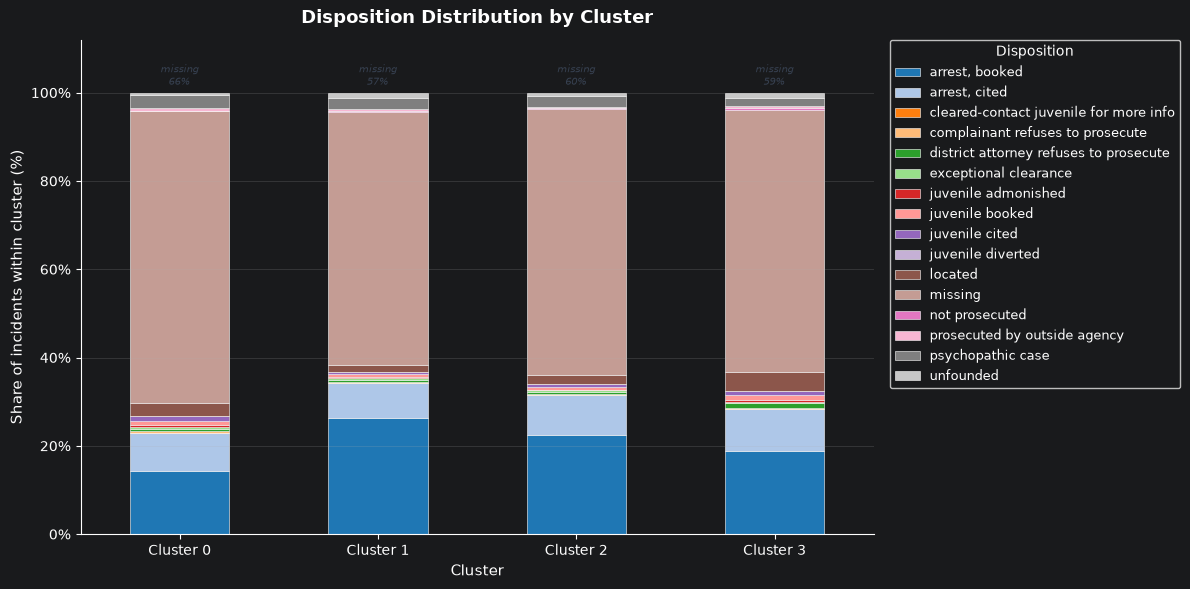

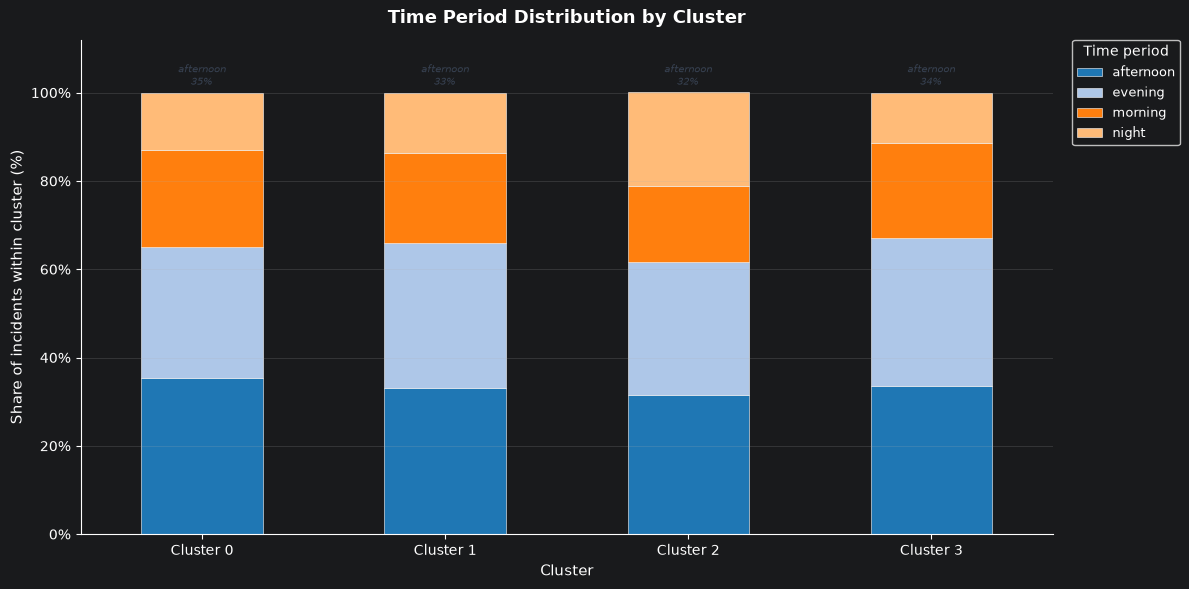

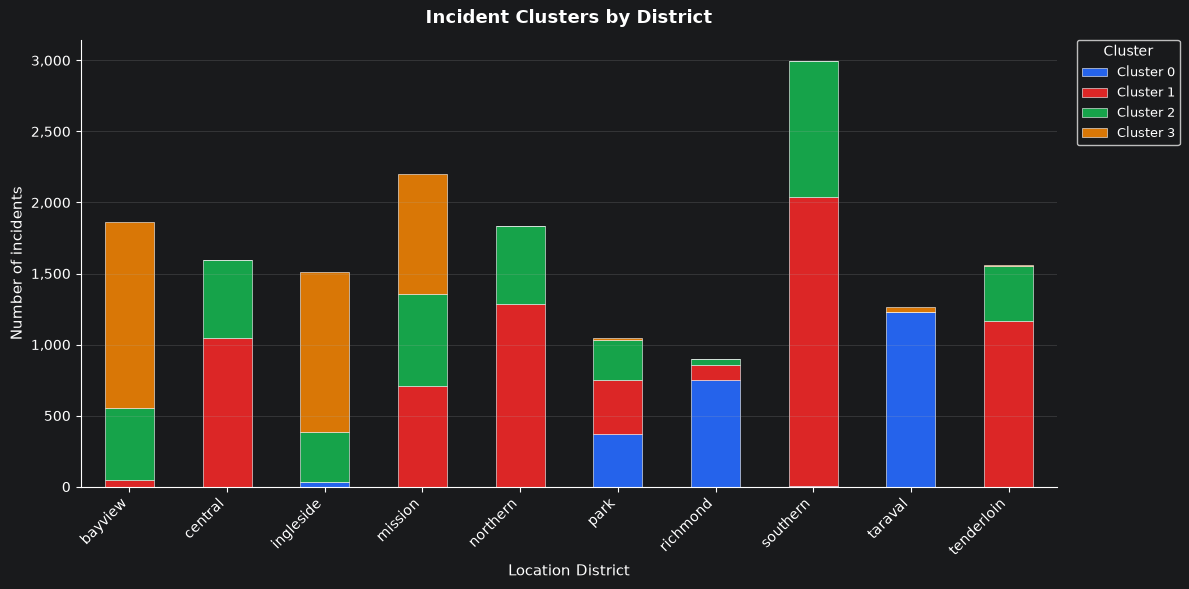

In [19]:
incident_reason_table = plot_stacked_distribution(
    df_clustered,
    row_col="cluster",
    category_col="incident_reason_simple",
    title="Top Incident Reason Distribution by Cluster",
    filename="incident_reason_by_cluster.png",
    top_n=10,
    legend_title="Incident reason",
)

disposition_table = plot_stacked_distribution(
    df_clustered,
    row_col="cluster",
    category_col="disposition_simple",
    title="Disposition Distribution by Cluster",
    filename="disposition_by_cluster.png",
    top_n=None,
    legend_title="Disposition",
)

time_period_table = plot_stacked_distribution(
    df_clustered,
    row_col="cluster",
    category_col="time_period",
    title="Time Period Distribution by Cluster",
    filename="time_period_by_cluster.png",
    top_n=None,
    legend_title="Time period",
)

cluster_district_table = plot_stacked_distribution(
    df_clustered,
    row_col="LOCATION_DISTRICT",
    category_col="cluster",
    title="Incident Clusters by District",
    filename="clusters_by_district.png",
    top_n=None,
    normalize=False,
    legend_title="Cluster",
)

## 10. Outputs

The most important files for the report are:

- `outputs/final_cluster_summary_for_report.csv`
- `outputs/cluster_counts.csv`
- `outputs/cluster_evaluation.csv`
- `outputs/figures/cluster_evaluation_combined.png` ← new: all 3 metrics in one panel
- `outputs/figures/svd_clusters_2d.png`
- `outputs/figures/geographic_cluster_distribution.png`
- `outputs/figures/incidents_per_cluster.png`
- `outputs/figures/incident_reason_by_cluster.png`
- `outputs/figures/disposition_by_cluster.png`

The clusters reveal recurring patterns in policing activity. They do not by themselves prove causal explanations or discrimination.